In [1]:
import os
os.environ["NUMBA_DISABLE_JIT"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from data.data_processor_fix import DataProcessor as DP
from data.splitter import SurvivalSplitter
from models.cox_model_upd import CoxModelUpd
from metrics.ibs import IBSMetric
from metrics.auprc import AUPRCMetric
from metrics.recurrent_count_error import RecurrentCountError
from survivors.constants import get_y

In [2]:
df = pd.read_csv('data/individual_custody_timeline_rfm.csv')
print(df.columns)

Index(['name', 'age', 'sex', 'race', 'c_charge_degree', 'c_charge_desc',
       'in_custody', 'out_custody', 'custody_num', 'time_to_last_custody',
       'time_since_last_arrest', 'time_to_future_arrest', 'event',
       'event_of_future_arrest', 'curr_dur_custody', 'sum_dur_custody',
       'average_dur_custody', 'all_future_arrest_times', 'all_future_events'],
      dtype='object')


In [3]:
processor = DP("data/individual_custody_timeline_rfm.csv")
cox_df = processor.load_and_prepare()
# cox_df.head(30)

Data split into train and test data

In [4]:
splitter = SurvivalSplitter(test_size=0.2)
train_df, test_df = splitter.split_by_individual(cox_df)
train_df = train_df.drop(columns=["curr_dur_custody"])
test_df = test_df.drop(columns=["curr_dur_custody"])

print("Train individuals:", train_df["name"].nunique())
print("Test individuals:", test_df["name"].nunique())

Train individuals: 3382
Test individuals: 845


In [5]:
train_df["time"] = train_df["stop"] - train_df["start"]
test_df["time"] = test_df["stop"] - test_df["start"]

survival_train = get_y(
    cens=train_df["event"].astype(bool),
    time=train_df["time"],
    competing=False
)

survival_test = get_y(
    cens=test_df["event"].astype(bool),
    time=test_df["time"],
    competing=False
)

In [6]:
train_df.query("name=='daniel diaz'")

,name,episode_col,start,stop,event,age,time_since_last_arrest,average_dur_custody,time
1171,daniel diaz,1,0,104,1,50,70.0,34.00,104
1172,daniel diaz,2,104,159,1,50,24.0,32.50,55
1173,daniel diaz,3,159,235,1,50,12.0,43.00,76
1174,daniel diaz,4,235,261,1,50,25.0,32.50,26
1175,daniel diaz,5,261,391,1,50,12.0,49.60,130
1176,daniel diaz,6,391,1079,1,50,509.0,71.17,688
1177,daniel diaz,7,1079,1088,1,50,7.0,61.29,9
1178,daniel diaz,8,1088,1128,0,50,6.0,57.88,40


In [7]:
features = [c for c in train_df.columns 
            if c not in ["name", "start", "time", "event", "stop"]]

cols_for_model = ["name", "start", "stop", "event", "time"] + features
train_model_df = train_df[cols_for_model].copy().fillna(-1)
test_df = test_df.fillna(-1)

invalid_mask = train_model_df["start"] >= train_model_df["stop"]
eps = 1e-6
train_model_df.loc[invalid_mask, "stop"] = train_model_df.loc[invalid_mask, "stop"] + eps

/var/folders/5x/6m24bsfj487bwk8kdp77nxy40000gn/T/ipykernel_82049/3542754420.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[213.000001 286.000001]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_model_df.loc[invalid_mask, "stop"] = train_model_df.loc[invalid_mask, "stop"] + eps


In [8]:
display(train_model_df.groupby("episode_col").size())
display(test_df.groupby("episode_col").size())

episode_col
1     3382
2     1503
3      680
4      304
5      148
6       77
7       37
8       11
9        5
10       2
dtype: int64

episode_col
1     845
2     435
3     184
4      78
5      34
6      16
7      13
8       5
9       4
10      4
11      3
12      2
dtype: int64

In [9]:
train_df

,name,episode_col,start,stop,event,age,time_since_last_arrest,average_dur_custody,time
0,aajah herrington,1,0,385,0,23,384.0,1.0,385
1,aaron aprile,1,0,55,0,27,0.0,55.0,55
2,aaron davis,1,0,432,0,41,314.0,118.0,432
3,aaron eddins,1,0,104,0,37,104.0,0.0,104
4,aaron epstein,1,0,297,1,22,296.0,1.0,297
...,...,...,...,...,...,...,...,...,...
6144,zavier harris,1,0,302,0,20,0.0,302.0,302
6145,zaysha clark,1,0,430,0,24,429.0,1.0,430
6146,zechariah faulk,1,0,69,0,28,69.0,0.0,69
6147,zeke zikria,1,0,152,0,46,150.0,2.0,152


In [10]:
test_model_df = test_df.query(f"episode_col.isin({train_model_df['episode_col'].unique().tolist()})")

In [11]:
horizon = np.quantile(train_model_df["stop"] - train_model_df["start"], 0.95)
times = np.linspace(0, horizon, 200)

In [12]:
import numpy as np
import pandas as pd
from lifelines.utils import concordance_index

class SurvivalEvaluator:
    def __init__(self, ibs_metric, auprc_metric):
        self.ibs_metric = ibs_metric
        self.auprc_metric = auprc_metric
        self.results = []

    def evaluate(
        self,
        model,
        model_name,
        train_df,
        test_df,
        features,
        times,
        duration_col="time",
        event_col="event",
    ):  
        predictions = model.predict_survival(test_df[features], times)
        estimate = predictions.values.astype(np.float64)

        survival_test = get_y(time=test_df[duration_col], cens=test_df[event_col].astype(bool))
        survival_train = get_y(time=train_df[duration_col], cens=train_df[event_col].astype(bool))

        mean_ibs, _ = self.ibs_metric.compute(survival_train, survival_test, estimate, times)
        mean_auprc = self.auprc_metric.compute(survival_train, survival_test, estimate, times)

        ci = concordance_index(
            survival_test["time"],
            np.trapz(estimate, times, axis=1),
            test_df[event_col]
        )

        tr_pred = model.predict_cumulative_hazard(train_df, times)
        tr_max = np.quantile(tr_pred.max(), 0.9)
        pred = model.predict_cumulative_hazard(test_df, times)
        
        recerr = RecurrentCountError()
        recurrent_error = recerr.compute(
            survival_train=None,
            survival_test=test_df,
            estimate=pred / tr_max,
            times=times
        )

        self.results.append({
            "model": model_name,
            "IBS": mean_ibs,
            "AUPRC": mean_auprc,
            "C-index": ci,
            "recurrent_error": recurrent_error
        })
        return mean_ibs, mean_auprc, ci, recurrent_error


    def get_results_table(self):
        return pd.DataFrame(self.results)

In [13]:
models = {}

for model_mode in ["recurrent", "independent"]:
    for use_episode in [True, False]:
        for penalizer in [0.0, 0.01, 0.1]:
            name = f"CoxUpd_{model_mode[:3]}_{'with' if use_episode else 'no'}_k_pen_{penalizer}"
            print(name)
            features_model = features.copy()
            if not(use_episode):
                features_model.remove("episode_col")

            model = CoxModelUpd(
                features=features_model,
                mode=model_mode,
                use_episode=use_episode,
                penalizer=penalizer    
            )
            if model_mode == "recurrent":
                model.fit(train_model_df[features_model + ["start", "stop", "name", "event"]])
            else:
                model.fit(train_model_df[features_model + ["time", "event"]])
            models[name] = model

CoxUpd_rec_with_k_pen_0.0


model,lifelines.CoxPHFitter
duration col,'stop'
event col,'event'
entry col,'start'
cluster col,'name'
robust variance,True
strata,episode_col
baseline estimation,breslow
number of observations,6149
number of events observed,2767
partial log-likelihood,-15242.40


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_rec_with_k_pen_0.01


model,lifelines.CoxPHFitter
duration col,'stop'
event col,'event'
entry col,'start'
cluster col,'name'
penalizer,0.01
l1 ratio,0.0
robust variance,True
strata,episode_col
baseline estimation,breslow
number of observations,6149


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_rec_with_k_pen_0.1


...

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_no_k_pen_0.01


<lifelines.CoxPHFitter: fitted with 6149 total observations, 3382 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 6149
number of events observed = 2767
   partial log-likelihood = -19149.79
         time fit was run = 2026-03-06 16:14:33 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
age                    -0.00      1.00      0.00           -0.01           -0.00                0.99                1.00
time_since_last_arrest -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
average_dur_custody    -0.03      0.97      0.00           -0.03           -0.03                0.97                0.97

                        cmp to      z      p  -log2(p)
covariate                                             
age                       0.00  -1.97   0.05      4.34
time_since_last_arrest    0.00 -57.94 <0.005       inf
average_dur_custody       0.00 -47.82 <0.005       inf
---
Concordance = 0.93
Partial AIC = 38305.57
log-likelihood ratio test = 5751.26 on 3 df
-log2(p) of ll-ratio test = inf

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_no_k_pen_0.1


<lifelines.CoxPHFitter: fitted with 6149 total observations, 3382 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 6149
number of events observed = 2767
   partial log-likelihood = -20522.24
         time fit was run = 2026-03-06 16:14:33 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
age                    -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
time_since_last_arrest -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
average_dur_custody    -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99

                        cmp to      z      p  -log2(p)
covariate                                             
age                       0.00  -3.48 <0.005     10.98
time_since_last_arrest    0.00 -50.72 <0.005       inf
average_dur_custody       0.00 -34.56 <0.005    867.11
---
Concordance = 0.94
Partial AIC = 41050.49
log-likelihood ratio test = 3006.34 on 3 df
-log2(p) of ll-ratio test = inf

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>


In [14]:
evaluator = SurvivalEvaluator(
    ibs_metric=IBSMetric(),
    auprc_metric=AUPRCMetric()
)

for name, model in models.items():
    evaluator.evaluate(
        model=model,
        model_name=name,
        train_df=train_model_df,
        test_df=test_model_df,
        features=features,
        times=times
    )

evaluator.get_results_table().round(4)

,model,IBS,AUPRC,C-index,recurrent_error
0,CoxUpd_rec_with_k_pen_0.0,0.3133,0.5812,0.5081,1.3438
1,CoxUpd_rec_with_k_pen_0.01,0.3002,0.5846,0.5066,1.2995
2,CoxUpd_rec_with_k_pen_0.1,0.2618,0.5921,0.5033,1.0569
3,CoxUpd_rec_no_k_pen_0.0,0.1746,0.6139,0.9362,0.6577
4,CoxUpd_rec_no_k_pen_0.01,0.1726,0.6138,0.9366,0.6415
5,CoxUpd_rec_no_k_pen_0.1,0.1717,0.6099,0.9361,0.5716
6,CoxUpd_ind_with_k_pen_0.0,0.0350,0.7940,0.9239,1.4012
7,CoxUpd_ind_with_k_pen_0.01,0.0370,0.7581,0.9306,1.2876
8,CoxUpd_ind_with_k_pen_0.1,0.0583,0.6782,0.9347,0.8163
9,CoxUpd_ind_no_k_pen_0.0,0.0352,0.7919,0.9294,1.3868


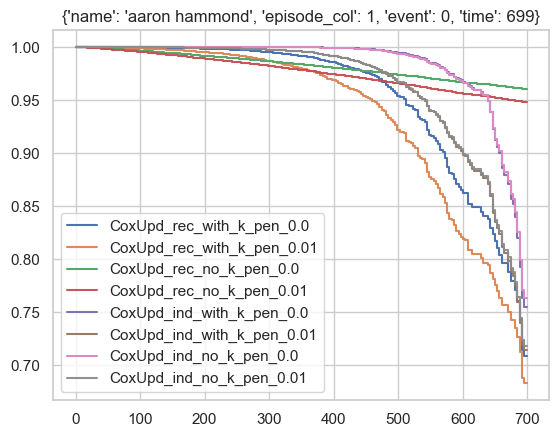

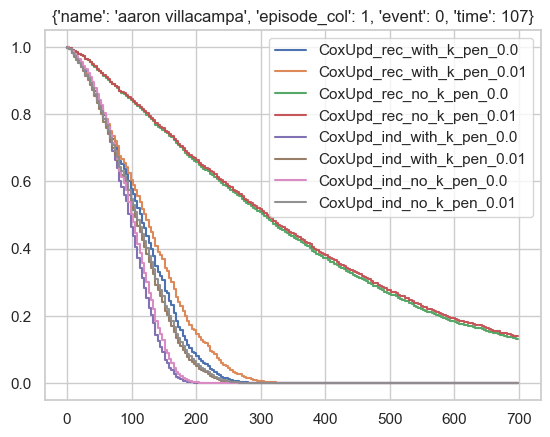

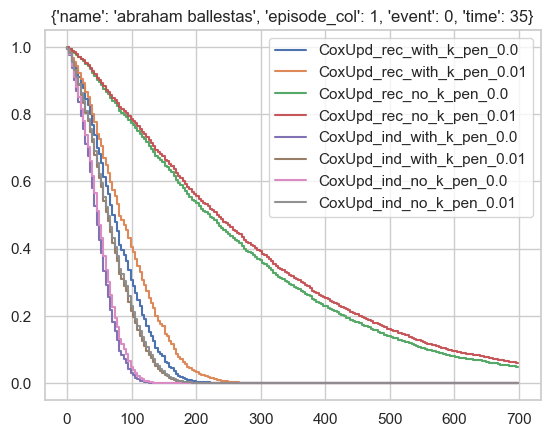

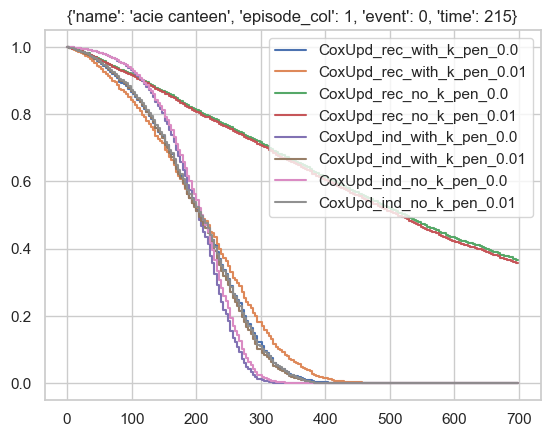

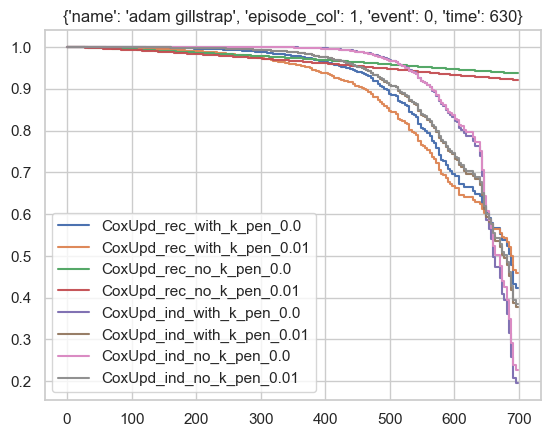

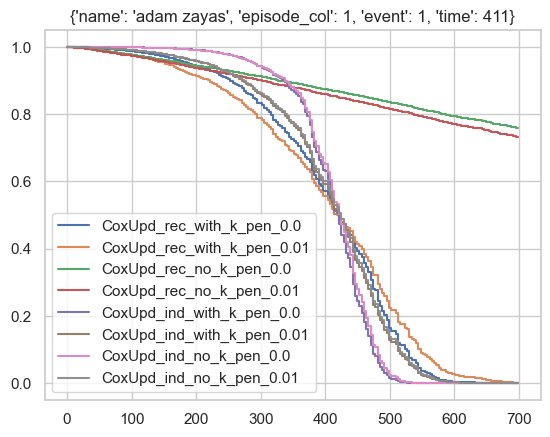

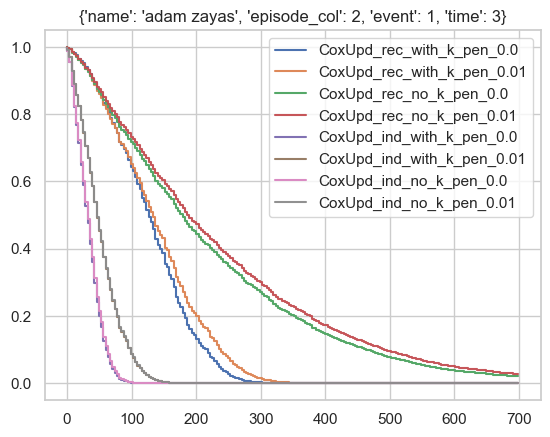

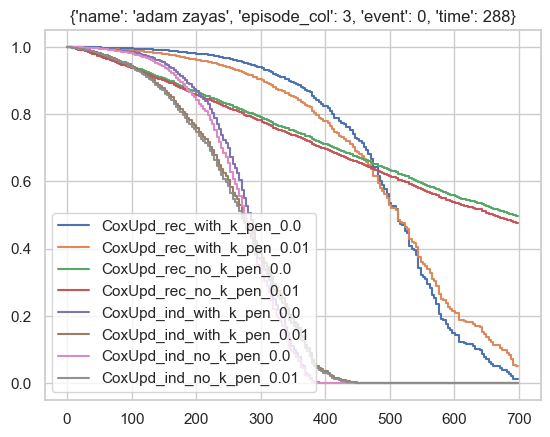

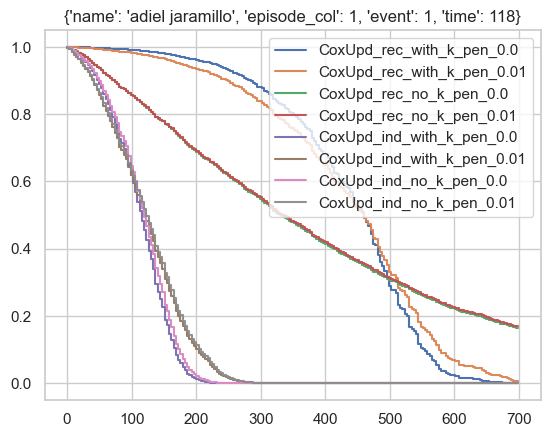

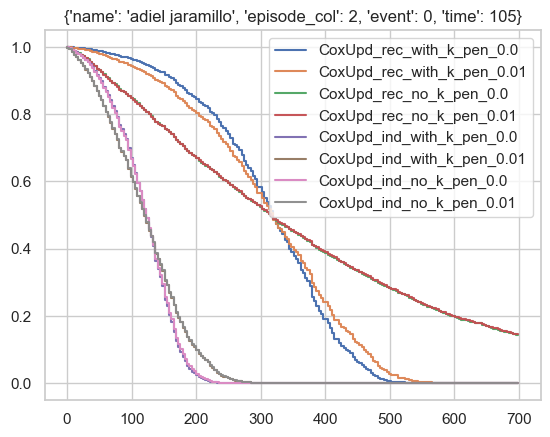

In [54]:
sns.set_style("whitegrid")

for index_test in range(10):
    for name, model in models.items():
        pen = float(name.split("_")[-1])
        if pen > 0.01:
            continue
        pred = model.predict_survival(test_model_df[features], times)
        plt.step(times, pred.iloc[index_test].values, label=name, alpha=0.01 ** pen)
    plt.legend()
    plt.title(f"{test_model_df.iloc[index_test][['name', 'episode_col', 'event', 'time']].to_dict()}")
    plt.show()